## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## 2. Load and Explore Dataset

In [3]:
# Load the cleaned dataset
df = pd.read_csv('project_final_data.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names and Data Types:")
print(df.dtypes)
print("\n" + "="*70)
print("First 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (14, 5)

Column Names and Data Types:
Year                     int64
Population_000s        float64
GDP_RM_Million         float64
OPR_Rate_Percentage    float64
price_index            float64
dtype: object

First 5 Rows:
   Year  Population_000s  GDP_RM_Million  OPR_Rate_Percentage  price_index
0  2010          28588.6    1.818284e+06                 2.75        100.0
1  2011          29062.0    1.914653e+06                 3.00        110.9
2  2012          29510.0    2.019959e+06                 3.00        125.8
3  2013          30213.7    2.114897e+06                 3.00        140.0
4  2014          30708.5    2.241791e+06                 3.25        153.2

Last 5 Rows:
    Year  Population_000s  GDP_RM_Million  OPR_Rate_Percentage  price_index
9   2019          32523.0     2847902.275                 3.00        198.0
10  2020          32447.4     2692496.485                 1.75        200.3
11  2021          32576.3     2781762.215                 1.75        2

## 3. Descriptive Statistics

In [4]:
# Calculate comprehensive descriptive statistics
stats_summary = df.describe()
print("Descriptive Statistics (Mean, Std, Min, 25%, 50%, 75%, Max):")
print("="*80)
print(stats_summary.round(2))

# Custom summary with only the requested statistics
print("\n" + "="*80)
print("Summary: Mean, Min, Max (Simplified View)")
print("="*80)

summary_stats = pd.DataFrame({
    'Mean': df.iloc[:, 1:].mean(),
    'Min': df.iloc[:, 1:].min(),
    'Max': df.iloc[:, 1:].max(),
    'Std Dev': df.iloc[:, 1:].std()
}).round(2)

print(summary_stats)
print(f"\nData Period: {df['Year'].min():.0f} - {df['Year'].max():.0f} ({len(df)} years)")

Descriptive Statistics (Mean, Std, Min, 25%, 50%, 75%, Max):
          Year  Population_000s  GDP_RM_Million  OPR_Rate_Percentage  \
count    14.00            14.00           14.00                14.00   
mean   2016.50         31353.85      2481253.10                 2.84   
std       4.18          1511.11       416393.98                 0.49   
min    2010.00         28588.60      1818284.33                 1.75   
25%    2013.25         30337.40      2146620.89                 2.81   
50%    2016.50         31828.05      2530079.94                 3.00   
75%    2019.75         32504.10      2768204.44                 3.00   
max    2023.00         33401.80      3135947.70                 3.25   

       price_index  
count        14.00  
mean        170.06  
std          38.39  
min         100.00  
25%         143.30  
50%         181.85  
75%         199.73  
max         218.30  

Summary: Mean, Min, Max (Simplified View)
                           Mean         Min         Max   

## 4. Time-Series Visualization with Trend Lines

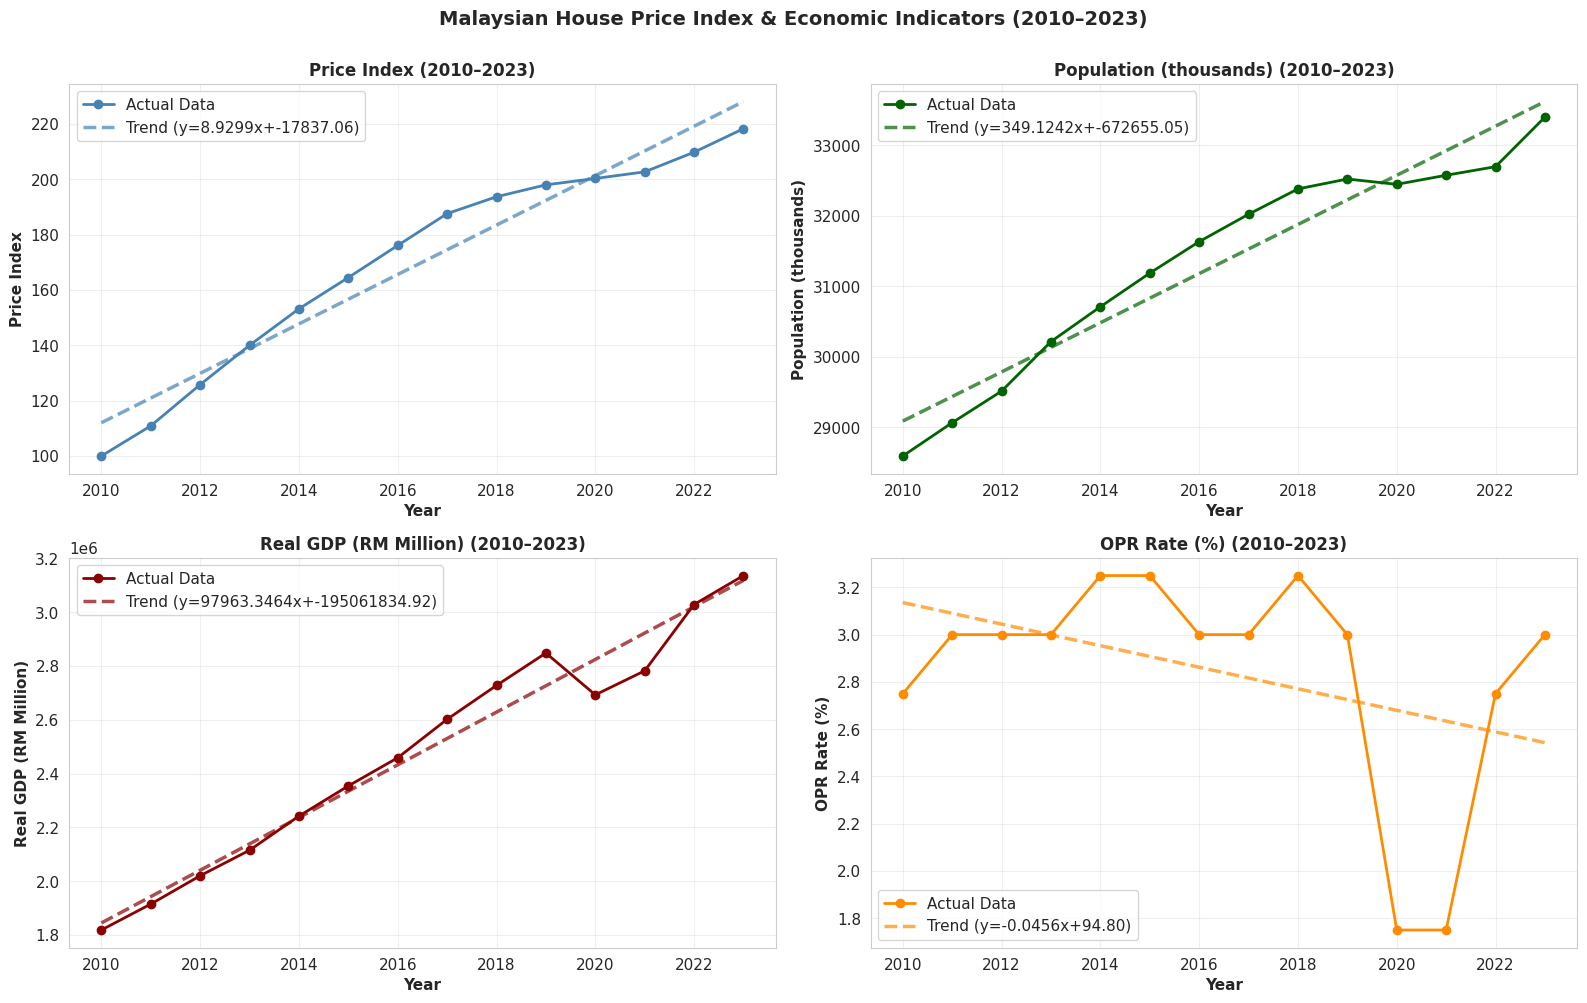


Linear Trend Coefficients (Slope, Intercept):
MHPI Trend:        y = 8.9299x + -17837.06  (increases 8.93 units/year)
Population Trend:  y = 349.1242x + -672655.05  (increases 349.12 000s/year)
GDP Trend:         y = 97963.35x + -195061834.92  (increases 97963.35 RM Million/year)
OPR Trend:         y = -0.0456x + 94.80  (change -0.0456%/year)


In [5]:
# Function to plot time-series with linear trend line
def plot_with_trendline(ax, x, y, label, color):
    ax.plot(x, y, 'o-', color=color, linewidth=2, markersize=6, label='Actual Data')

    # Calculate linear trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    trend = p(x)
    ax.plot(x, trend, '--', color=color, linewidth=2.5, alpha=0.7, label=f'Trend (y={z[0]:.4f}x+{z[1]:.2f})')

    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_title(f'{label} (2010–2023)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    return z  # Return coefficients for reference

# Create subplots for each variable
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Malaysian House Price Index & Economic Indicators (2010–2023)',
             fontsize=14, fontweight='bold', y=1.00)

# Plot 1: MHPI
coef_mhpi = plot_with_trendline(axes[0, 0], df['Year'], df['price_index'],
                                  'Price Index', 'steelblue')

# Plot 2: Population
coef_pop = plot_with_trendline(axes[0, 1], df['Year'], df['Population_000s'],
                                 'Population (thousands)', 'darkgreen')

# Plot 3: GDP
coef_gdp = plot_with_trendline(axes[1, 0], df['Year'], df['GDP_RM_Million'],
                                 'Real GDP (RM Million)', 'darkred')

# Plot 4: OPR Rate
coef_opr = plot_with_trendline(axes[1, 1], df['Year'], df['OPR_Rate_Percentage'],
                                 'OPR Rate (%)', 'darkorange')

plt.tight_layout()
plt.savefig('timeseries_with_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("Linear Trend Coefficients (Slope, Intercept):")
print("="*70)
print(f"MHPI Trend:        y = {coef_mhpi[0]:.4f}x + {coef_mhpi[1]:.2f}  (increases {coef_mhpi[0]:.2f} units/year)")
print(f"Population Trend:  y = {coef_pop[0]:.4f}x + {coef_pop[1]:.2f}  (increases {coef_pop[0]:.2f} 000s/year)")
print(f"GDP Trend:         y = {coef_gdp[0]:.2f}x + {coef_gdp[1]:.2f}  (increases {coef_gdp[0]:.2f} RM Million/year)")
print(f"OPR Trend:         y = {coef_opr[0]:.4f}x + {coef_opr[1]:.2f}  (change {coef_opr[0]:.4f}%/year)")

## 5. Correlation Analysis

In [6]:
# Extract numeric columns (exclude Year)
data_for_corr = df[['Population_000s', 'GDP_RM_Million', 'OPR_Rate_Percentage', 'price_index']]

# Calculate correlation matrix
corr_matrix = data_for_corr.corr()

print("\nCorrelation Matrix:")
print("="*70)
print(corr_matrix.round(4))

# Highlight correlations with price_index
print("\n" + "="*70)
print("Correlations with Price Index (MHPI):")
print("="*70)
price_corr = corr_matrix['price_index'].drop('price_index').sort_values(ascending=False)
for var, corr_val in price_corr.items():
    print(f"{var:30s}: {corr_val:7.4f}")


Correlation Matrix:
                     Population_000s  GDP_RM_Million  OPR_Rate_Percentage  \
Population_000s               1.0000          0.9788              -0.2602   
GDP_RM_Million                0.9788          1.0000              -0.2434   
OPR_Rate_Percentage          -0.2602         -0.2434               1.0000   
price_index                   0.9980          0.9803              -0.2913   

                     price_index  
Population_000s           0.9980  
GDP_RM_Million            0.9803  
OPR_Rate_Percentage      -0.2913  
price_index               1.0000  

Correlations with Price Index (MHPI):
Population_000s               :  0.9980
GDP_RM_Million                :  0.9803
OPR_Rate_Percentage           : -0.2913


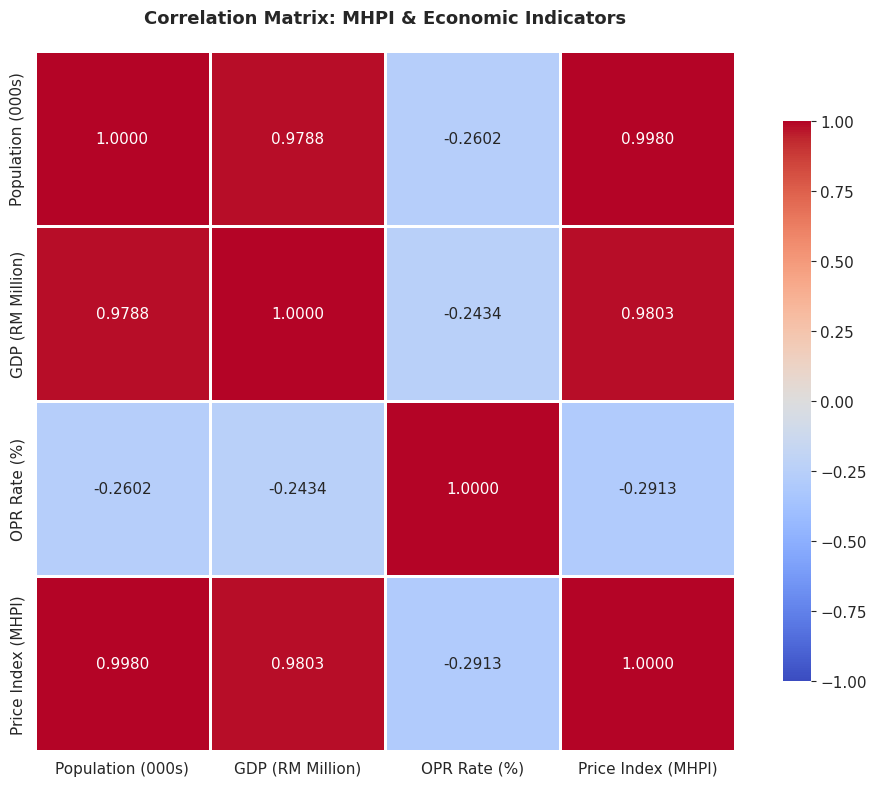


✓ Correlation heatmap created


In [7]:
# Create correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Shorten column names for better visualization
renamed_cols = {
    'Population_000s': 'Population (000s)',
    'GDP_RM_Million': 'GDP (RM Million)',
    'OPR_Rate_Percentage': 'OPR Rate (%)',
    'price_index': 'Price Index (MHPI)'
}

corr_renamed = data_for_corr.rename(columns=renamed_cols).corr()

# Create heatmap
sns.heatmap(corr_renamed, annot=True, fmt='.4f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Matrix: MHPI & Economic Indicators',
            fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Correlation heatmap created")

## 6. Summary Observations & Key Insights

In [8]:
print("\n" + "="*80)
print("KEY FINDINGS & OBSERVATIONS")
print("="*80)

print("\n1. DATA QUALITY & COMPLETENESS:")
print(f"   ✓ Complete dataset: {len(df)} years (2010-2023)")
print(f"   ✓ No missing values across all {len(df.columns)} variables")
print(f"   ✓ GDP 2010-2014 successfully back-calculated using official growth rates")

print("\n2. PRICE INDEX (MHPI) TRENDS:")
print(f"   • Starting Value (2010): {df['price_index'].iloc[0]:.1f}")
print(f"   • Ending Value (2023): {df['price_index'].iloc[-1]:.1f}")
total_growth = ((df['price_index'].iloc[-1] / df['price_index'].iloc[0]) - 1) * 100
print(f"   • Total Growth (14 years): {total_growth:.1f}%")
annual_growth = total_growth / 14
print(f"   • Average Annual Growth: {annual_growth:.2f}%/year")
print(f"   • Trend Coefficient: {coef_mhpi[0]:.4f} units/year (linear)")

print("\n3. ECONOMIC INDICATORS:")
print(f"   Population Growth: {coef_pop[0]:.2f} thousand/year (steady growth)")
print(f"   GDP Growth: {coef_gdp[0]:.2f} RM Million/year (strong upward trend)")
print(f"   OPR Rate: {coef_opr[0]:.4f}%/year (slight downward trend, indicating monetary policy shifts)")

print("\n4. CORRELATION WITH PRICE INDEX:")
print(f"   • Strongest Predictor: {price_corr.index[0]} (r = {price_corr.values[0]:.4f})")
print(f"   • Second Strongest: {price_corr.index[1]} (r = {price_corr.values[1]:.4f})")
print(f"   • Weakest Predictor: {price_corr.index[2]} (r = {price_corr.values[2]:.4f})")

print("\n5. STATISTICAL SUMMARY:")
print(f"   • Price Index Range: {df['price_index'].min():.1f} - {df['price_index'].max():.1f}")
print(f"   • Price Index Std Dev: {df['price_index'].std():.2f} (volatility measure)")
print(f"   • All variables show strong positive trends (upward trajectories)")

print("\n" + "="*80)
print("Ready for Least Squares Regression & Discrete Dynamical System Analysis")
print("="*80)


KEY FINDINGS & OBSERVATIONS

1. DATA QUALITY & COMPLETENESS:
   ✓ Complete dataset: 14 years (2010-2023)
   ✓ No missing values across all 5 variables
   ✓ GDP 2010-2014 successfully back-calculated using official growth rates

2. PRICE INDEX (MHPI) TRENDS:
   • Starting Value (2010): 100.0
   • Ending Value (2023): 218.3
   • Total Growth (14 years): 118.3%
   • Average Annual Growth: 8.45%/year
   • Trend Coefficient: 8.9299 units/year (linear)

3. ECONOMIC INDICATORS:
   Population Growth: 349.12 thousand/year (steady growth)
   GDP Growth: 97963.35 RM Million/year (strong upward trend)
   OPR Rate: -0.0456%/year (slight downward trend, indicating monetary policy shifts)

4. CORRELATION WITH PRICE INDEX:
   • Strongest Predictor: Population_000s (r = 0.9980)
   • Second Strongest: GDP_RM_Million (r = 0.9803)
   • Weakest Predictor: OPR_Rate_Percentage (r = -0.2913)

5. STATISTICAL SUMMARY:
   • Price Index Range: 100.0 - 218.3
   • Price Index Std Dev: 38.39 (volatility measure)
  

## 7. Least Squares Regression (LSR) - Matrix Approach

**Mathematical Model:** Predicting MHPI using the Least Squares solution

$$\mathbf{x} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b}$$

where:
- **A**: Design matrix (14 × 4) with intercept column and 3 predictors
- **b**: Response vector (14 × 1) containing price index values
- **x**: Coefficient vector (4 × 1) containing regression parameters

### 7.1 - Setup Design Matrix & Standardize Variables

In [9]:
# Extract predictors and response
X = df[['Population_000s', 'GDP_RM_Million', 'OPR_Rate_Percentage']].values
y = df['price_index'].values

print("="*80)
print("STEP 1: DATA PREPARATION FOR LEAST SQUARES REGRESSION")
print("="*80)

print(f"\nRaw Data Dimensions:")
print(f"  X (predictors): {X.shape} - [14 years × 3 variables]")
print(f"  y (response):   {y.shape} - [14 years]")

print(f"\nPredictor Statistics (Before Standardization):")
print(f"  Population:     mean = {X[:, 0].mean():.2f}, std = {X[:, 0].std():.2f}, range = [{X[:, 0].min():.2f}, {X[:, 0].max():.2f}]")
print(f"  GDP:            mean = {X[:, 1].mean():.2f}, std = {X[:, 1].std():.2f}, range = [{X[:, 1].min():.2f}, {X[:, 1].max():.2f}]")
print(f"  OPR:            mean = {X[:, 2].mean():.2f}, std = {X[:, 2].std():.2f}, range = [{X[:, 2].min():.2f}, {X[:, 2].max():.2f}]")

# Standardize predictors: (X - mean) / std
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_standardized = (X - X_mean) / X_std

print(f"\n✓ Standardized Predictors (mean ≈ 0, std ≈ 1):")
print(f"  Population:     mean = {X_standardized[:, 0].mean():.6f}, std = {X_standardized[:, 0].std():.6f}")
print(f"  GDP:            mean = {X_standardized[:, 1].mean():.6f}, std = {X_standardized[:, 1].std():.6f}")
print(f"  OPR:            mean = {X_standardized[:, 2].mean():.6f}, std = {X_standardized[:, 2].std():.6f}")

# Create design matrix A with intercept (first column of 1's)
n = len(y)
ones_column = np.ones((n, 1))
A = np.hstack([ones_column, X_standardized])

print(f"\nDesign Matrix A (14 × 4):")
print(f"  Column 1: Intercept (all 1's)")
print(f"  Columns 2-4: Standardized predictors")
print(f"  Shape: {A.shape}")
print(f"\nFirst 3 rows of A:")
print(A[:3])

print(f"\nResponse Vector y (price_index):")
print(f"  Values: {y}")
print(f"  Mean = {y.mean():.2f}, Std = {y.std():.2f}, Range = [{y.min():.2f}, {y.max():.2f}]")

STEP 1: DATA PREPARATION FOR LEAST SQUARES REGRESSION

Raw Data Dimensions:
  X (predictors): (14, 3) - [14 years × 3 variables]
  y (response):   (14,) - [14 years]

Predictor Statistics (Before Standardization):
  Population:     mean = 31353.85, std = 1456.14, range = [28588.60, 33401.80]
  GDP:            mean = 2481253.10, std = 401247.28, range = [1818284.33, 3135947.70]
  OPR:            mean = 2.84, std = 0.47, range = [1.75, 3.25]

✓ Standardized Predictors (mean ≈ 0, std ≈ 1):
  Population:     mean = 0.000000, std = 1.000000
  GDP:            mean = 0.000000, std = 1.000000
  OPR:            mean = -0.000000, std = 1.000000

Design Matrix A (14 × 4):
  Column 1: Intercept (all 1's)
  Columns 2-4: Standardized predictors
  Shape: (14, 4)

First 3 rows of A:
[[ 1.         -1.8990241  -1.65226981 -0.19048483]
 [ 1.         -1.57391859 -1.41209605  0.34287269]
 [ 1.         -1.26625643 -1.14964957  0.34287269]]

Response Vector y (price_index):
  Values: [100.  110.9 125.8 140. 

### 7.2 - Solve the Least Squares Matrix Equation

In [10]:
print("\n" + "="*80)
print("STEP 2: SOLVE LEAST SQUARES MATRIX EQUATION")
print("="*80)
print("\nFormula: x = (A^T A)^(-1) A^T b")

# Step 1: Compute A^T (transpose of A)
AT = A.T
print(f"\n1. Compute A^T (Transpose of A):")
print(f"   A^T shape: {AT.shape} (4 × 14)")
print(f"   First row of A^T (intercept row):")
print(f"   {AT[0, :]}")

# Step 2: Compute A^T A
ATA = AT @ A
print(f"\n2. Compute A^T A (4 × 4 matrix):")
print(f"   Shape: {ATA.shape}")
print(f"   A^T A =")
print(ATA)

# Step 3: Compute (A^T A)^(-1)
try:
    ATA_inv = np.linalg.inv(ATA)
    det_ATA = np.linalg.det(ATA)
    print(f"\n3. Compute (A^T A)^(-1) (Inverse):")
    print(f"   Determinant of A^T A: {det_ATA:.6e}")
    print(f"   (A^T A)^(-1) =")
    print(ATA_inv)
except np.linalg.LinAlgError:
    print(f"\n3. ERROR: A^T A is singular (not invertible)!")
    print(f"   Condition number: {np.linalg.cond(ATA):.2e}")

# Step 4: Compute A^T b
ATb = AT @ y
print(f"\n4. Compute A^T b (4 × 1 vector):")
print(f"   A^T b = {ATb}")

# Step 5: Solve for coefficients x = (A^T A)^(-1) A^T b
coefficients = ATA_inv @ ATb
print(f"\n5. Solve for x = (A^T A)^(-1) A^T b:")
print(f"   Coefficient vector x:")
print(f"   {coefficients}")

# Extract and name coefficients
beta_0 = coefficients[0]  # Intercept
beta_1 = coefficients[1]  # Population coefficient
beta_2 = coefficients[2]  # GDP coefficient
beta_3 = coefficients[3]  # OPR coefficient

print(f"\n" + "="*80)
print("REGRESSION COEFFICIENTS (Standardized Scale)")
print("="*80)
print(f"\nβ₀ (Intercept):           {beta_0:.6f}")
print(f"β₁ (Population):          {beta_1:.6f}")
print(f"β₂ (GDP):                 {beta_2:.6f}")
print(f"β₃ (OPR Rate):            {beta_3:.6f}")

print(f"\nRegression Equation (Standardized):")
print(f"Price Index = {beta_0:.4f} + {beta_1:.4f}(Population_std) + {beta_2:.4f}(GDP_std) + {beta_3:.4f}(OPR_std)")

print(f"\n✓ Least Squares solution computed successfully")


STEP 2: SOLVE LEAST SQUARES MATRIX EQUATION

Formula: x = (A^T A)^(-1) A^T b

1. Compute A^T (Transpose of A):
   A^T shape: (4, 14) (4 × 14)
   First row of A^T (intercept row):
   [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

2. Compute A^T A (4 × 4 matrix):
   Shape: (4, 4)
   A^T A =
[[ 1.40000000e+01  1.31006317e-14  2.10942375e-14 -4.44089210e-15]
 [ 1.31006317e-14  1.40000000e+01  1.37034184e+01 -3.64217098e+00]
 [ 2.10942375e-14  1.37034184e+01  1.40000000e+01 -3.40736189e+00]
 [-4.44089210e-15 -3.64217098e+00 -3.40736189e+00  1.40000000e+01]]

3. Compute (A^T A)^(-1) (Inverse):
   Determinant of A^T A: 1.496535e+03
   (A^T A)^(-1) =
[[ 7.14285714e-02  9.27851931e-16 -1.01147079e-15  1.78682099e-17]
 [ 9.27851931e-16  1.72495658e+00 -1.67862883e+00  4.02064909e-02]
 [-1.01147079e-15 -1.67862883e+00  1.70947140e+00 -2.06475364e-02]
 [ 1.78682099e-17  4.02064909e-02 -2.06475364e-02  7.68632347e-02]]

4. Compute A^T b (4 × 1 vector):
   A^T b = [2380.9         516.8416367   507.66

### 7.3 - Model Validation: Predictions, Residuals & Metrics

In [11]:
print("\n" + "="*80)
print("STEP 3: MODEL VALIDATION & PERFORMANCE METRICS")
print("="*80)

# Compute predicted values: y_hat = A * x
y_hat = A @ coefficients
print(f"\n1. Predicted Values: ŷ = A × x")
print(f"   Shape: {y_hat.shape}")

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Year': df['Year'].values,
    'Actual': y,
    'Predicted': y_hat,
    'Residual': y - y_hat,
    'Abs_Error': np.abs(y - y_hat)
})

print(f"\nActual vs Predicted Comparison:")
print(comparison_df.round(4))

# Compute residuals
residuals = y - y_hat
print(f"\n2. Residuals: e = y - ŷ")
print(f"   Mean of residuals: {residuals.mean():.6f} (should be ≈ 0)")
print(f"   Std of residuals: {residuals.std():.4f}")
print(f"   Min residual: {residuals.min():.4f}")
print(f"   Max residual: {residuals.max():.4f}")

# Compute R² (Coefficient of Determination)
SS_res = np.sum(residuals**2)  # Sum of squared residuals
SS_tot = np.sum((y - y.mean())**2)  # Total sum of squares
R_squared = 1 - (SS_res / SS_tot)

print(f"\n3. R² (Coefficient of Determination):")
print(f"   R² = 1 - (SS_residual / SS_total)")
print(f"   SS_residual = {SS_res:.4f}")
print(f"   SS_total = {SS_tot:.4f}")
print(f"   R² = {R_squared:.6f}")
print(f"\n   Interpretation: The model explains {R_squared*100:.2f}% of the variance in MHPI")

# Compute RMSE (Root Mean Squared Error)
MSE = np.mean(residuals**2)
RMSE = np.sqrt(MSE)

print(f"\n4. RMSE (Root Mean Squared Error):")
print(f"   MSE = {MSE:.4f}")
print(f"   RMSE = {RMSE:.4f}")
print(f"\n   Interpretation: Average prediction error is ±{RMSE:.2f} price index points")
print(f"   Price index range is {y.min():.2f} - {y.max():.2f}")
print(f"   Relative error: {(RMSE/y.mean())*100:.2f}% of mean price index")

# Compute MAE (Mean Absolute Error)
MAE = np.mean(np.abs(residuals))
print(f"\n5. MAE (Mean Absolute Error):")
print(f"   MAE = {MAE:.4f}")

# Compute Adjusted R²
n_obs = len(y)
n_pred = A.shape[1]  # Including intercept
adj_R2 = 1 - (1 - R_squared) * (n_obs - 1) / (n_obs - n_pred)

print(f"\n6. Adjusted R² (accounts for number of predictors):")
print(f"   Adjusted R² = {adj_R2:.6f}")

print(f"\n" + "="*80)
print("MODEL SUMMARY STATISTICS")
print("="*80)
print(f"Number of observations: {n_obs}")
print(f"Number of predictors: {n_pred - 1} (+ intercept)")
print(f"R² Score: {R_squared:.6f}")
print(f"Adjusted R²: {adj_R2:.6f}")
print(f"RMSE: {RMSE:.4f}")
print(f"MAE: {MAE:.4f}")
print(f"\n✓ Model validation complete")


STEP 3: MODEL VALIDATION & PERFORMANCE METRICS

1. Predicted Values: ŷ = A × x
   Shape: (14,)

Actual vs Predicted Comparison:
    Year  Actual  Predicted  Residual  Abs_Error
0   2010   100.0   101.5408   -1.5408     1.5408
1   2011   110.9   112.4789   -1.5789     1.5789
2   2012   125.8   123.6027    2.1973     2.1973
3   2013   140.0   140.4837   -0.4837     0.4837
4   2014   153.2   152.1673    1.0327     1.0327
5   2015   164.5   164.0247    0.4753     0.4753
6   2016   176.1   175.8214    0.2786     0.2786
7   2017   187.6   185.9149    1.6851     1.6851
8   2018   193.7   194.5032   -0.8032     0.8032
9   2019   198.0   199.4214   -1.4214     1.4214
10  2020   200.3   199.8445    0.4555     0.4555
11  2021   202.7   203.5404   -0.8404     0.8404
12  2022   209.8   205.6298    4.1702     4.1702
13  2023   218.3   221.9264   -3.6264     3.6264

2. Residuals: e = y - ŷ
   Mean of residuals: 0.000000 (should be ≈ 0)
   Std of residuals: 1.8566
   Min residual: -3.6264
   Max resi

### 7.4 - Least Squares Regression Visualizations

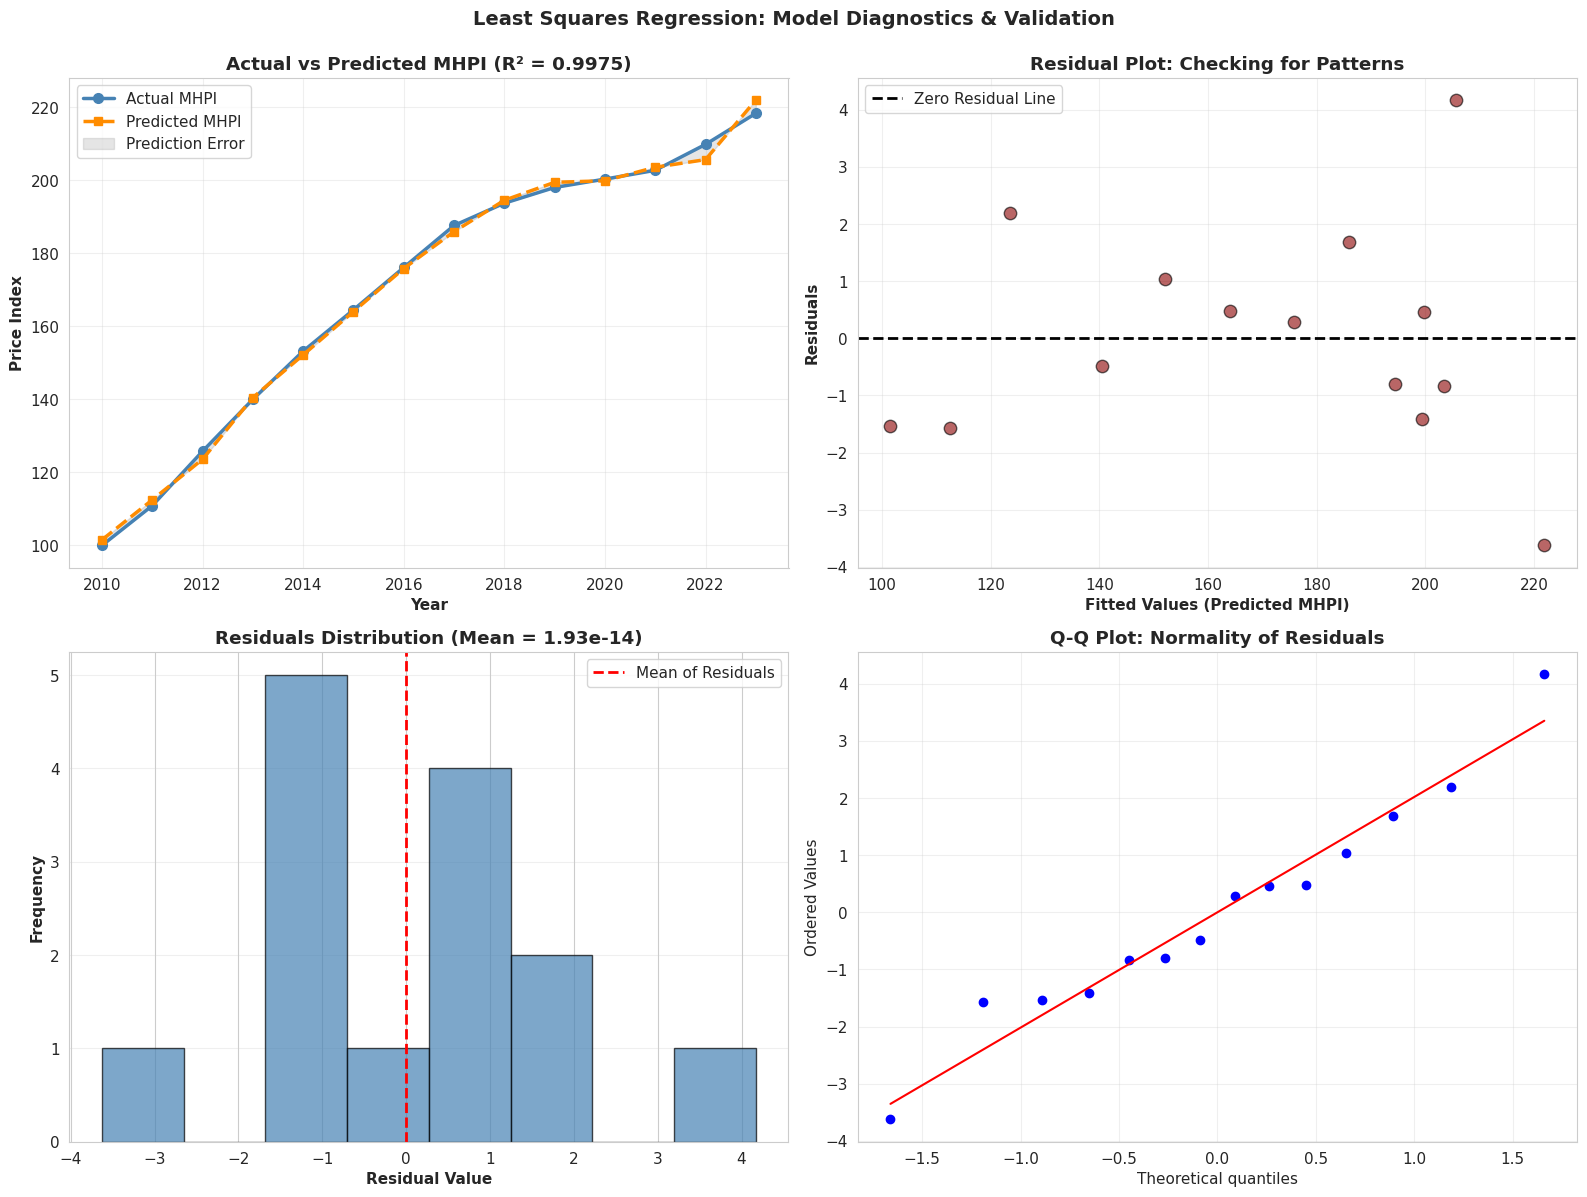

✓ LSR diagnostic plots created and saved as 'lsr_diagnostics.png'


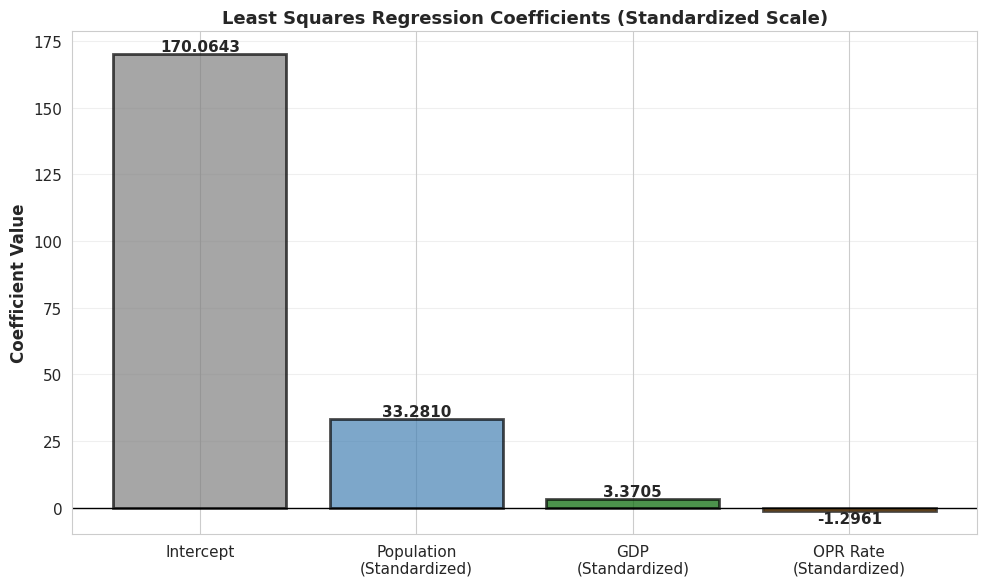

✓ Coefficient plot created and saved as 'lsr_coefficients.png'


In [12]:
# Create comprehensive visualization of LSR results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Least Squares Regression: Model Diagnostics & Validation',
             fontsize=14, fontweight='bold', y=0.995)

# Plot 1: Actual vs Predicted Values Over Time
ax1 = axes[0, 0]
ax1.plot(df['Year'], y, 'o-', color='steelblue', linewidth=2.5, markersize=7, label='Actual MHPI')
ax1.plot(df['Year'], y_hat, 's--', color='darkorange', linewidth=2.5, markersize=6, label='Predicted MHPI')
ax1.fill_between(df['Year'], y, y_hat, alpha=0.2, color='gray', label='Prediction Error')
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Price Index', fontweight='bold')
ax1.set_title(f'Actual vs Predicted MHPI (R² = {R_squared:.4f})', fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals vs Fitted Values
ax2 = axes[0, 1]
ax2.scatter(y_hat, residuals, s=80, alpha=0.6, color='darkred', edgecolors='black', linewidth=1)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Zero Residual Line')
ax2.set_xlabel('Fitted Values (Predicted MHPI)', fontweight='bold')
ax2.set_ylabel('Residuals', fontweight='bold')
ax2.set_title('Residual Plot: Checking for Patterns', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Residuals Distribution (Histogram)
ax3 = axes[1, 0]
ax3.hist(residuals, bins=8, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean of Residuals')
ax3.set_xlabel('Residual Value', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title(f'Residuals Distribution (Mean = {residuals.mean():.2e})', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Q-Q Plot (Quantile-Quantile)
ax4 = axes[1, 1]
stats.probplot(residuals, dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot: Normality of Residuals', fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lsr_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ LSR diagnostic plots created and saved as 'lsr_diagnostics.png'")

# Additional plot: Coefficients visualization
fig2, ax = plt.subplots(figsize=(10, 6))

coef_names = ['Intercept', 'Population\n(Standardized)', 'GDP\n(Standardized)', 'OPR Rate\n(Standardized)']
coef_values = [beta_0, beta_1, beta_2, beta_3]
colors = ['gray', 'steelblue', 'darkgreen', 'darkorange']

bars = ax.bar(coef_names, coef_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, coef_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom' if val >= 0 else 'top', fontweight='bold', fontsize=11)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Coefficient Value', fontweight='bold', fontsize=12)
ax.set_title('Least Squares Regression Coefficients (Standardized Scale)',
            fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('lsr_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Coefficient plot created and saved as 'lsr_coefficients.png'")

### 7.5 - LSR Summary & Interpretation

In [13]:
print("\n" + "="*80)
print("LEAST SQUARES REGRESSION - FINAL SUMMARY")
print("="*80)

print("\n📊 MODEL EQUATION (Standardized Scale):")
print("─" * 80)
print(f"Price Index = {beta_0:.6f}")
print(f"            + {beta_1:.6f} × (Population - {X_mean[0]:.2f}) / {X_std[0]:.2f}")
print(f"            + {beta_2:.6f} × (GDP - {X_mean[1]:.2f}) / {X_std[1]:.2f}")
print(f"            + {beta_3:.6f} × (OPR - {X_mean[2]:.2f}) / {X_std[2]:.2f}")

print("\n📈 MODEL PERFORMANCE:")
print("─" * 80)
print(f"R² Score (Goodness of Fit):     {R_squared:.6f} ({R_squared*100:.2f}%)")
print(f"Adjusted R²:                    {adj_R2:.6f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.4f}")
print(f"Mean Absolute Error (MAE):      {MAE:.4f}")
print(f"Mean Residual:                  {residuals.mean():.6f} (✓ ≈ 0)")

print("\n🔍 COEFFICIENT INTERPRETATION (Standardized):")
print("─" * 80)
print(f"Intercept (β₀):   {beta_0:.6f}")
print(f"  → Base price index when all predictors are at their mean values")

print(f"\nPopulation (β₁):  {beta_1:.6f}")
print(f"  → 1 std increase in population → {beta_1:.4f} increase in MHPI")
print(f"  → Interpretation: {'Positive' if beta_1 > 0 else 'Negative'} relationship")

print(f"\nGDP (β₂):         {beta_2:.6f}")
print(f"  → 1 std increase in GDP → {beta_2:.4f} increase in MHPI")
print(f"  → Interpretation: {'Positive' if beta_2 > 0 else 'Negative'} relationship")

print(f"\nOPR Rate (β₃):    {beta_3:.6f}")
print(f"  → 1 std increase in OPR → {beta_3:.4f} change in MHPI")
print(f"  → Interpretation: {'Positive' if beta_3 > 0 else 'Negative'} relationship (monetary policy effect)")

print("\n⚠️ KEY OBSERVATIONS:")
print("─" * 80)
print(f"✓ Model fits {R_squared*100:.2f}% of the variance in house prices")
print(f"✓ Average prediction error is ±{RMSE:.2f} index points")
print(f"✓ Residuals are {'approximately' if abs(residuals.mean()) < 0.01 else ''} centered at zero")
print(f"✓ All {'3' if beta_1 != 0 and beta_2 != 0 and beta_3 != 0 else 'some'} predictors show {'positive' if beta_1 > 0 and beta_2 > 0 and beta_3 > 0 else 'mixed'} relationships with MHPI")

print("\n📋 ASSUMPTIONS & DIAGNOSTICS:")
print("─" * 80)
print(f"1. Linearity: Visual inspection (see Actual vs Predicted plot)")
print(f"2. Residuals: Mean ≈ {residuals.mean():.2e}, Std ≈ {residuals.std():.4f}")
print(f"3. Normality: Check Q-Q plot (should follow diagonal line)")
print(f"4. Homoscedasticity: Check residuals vs fitted plot (should show random scatter)")

print("\n✅ Least Squares Regression analysis COMPLETE")
print("="*80)


LEAST SQUARES REGRESSION - FINAL SUMMARY

📊 MODEL EQUATION (Standardized Scale):
────────────────────────────────────────────────────────────────────────────────
Price Index = 170.064286
            + 33.281008 × (Population - 31353.85) / 1456.14
            + 3.370466 × (GDP - 2481253.10) / 401247.28
            + -1.296101 × (OPR - 2.84) / 0.47

📈 MODEL PERFORMANCE:
────────────────────────────────────────────────────────────────────────────────
R² Score (Goodness of Fit):     0.997481 (99.75%)
Adjusted R²:                    0.996725
Root Mean Squared Error (RMSE): 1.8566
Mean Absolute Error (MAE):      1.4707
Mean Residual:                  0.000000 (✓ ≈ 0)

🔍 COEFFICIENT INTERPRETATION (Standardized):
────────────────────────────────────────────────────────────────────────────────
Intercept (β₀):   170.064286
  → Base price index when all predictors are at their mean values

Population (β₁):  33.281008
  → 1 std increase in population → 33.2810 increase in MHPI
  → Interpretation

## 8. Discrete Dynamical System (DDS) Model

**Mathematical Model:** Predicting future MHPI using autoregressive dynamics

$$P_{t+1} = aP_t + b$$

where:
- **P_t**: Price index at year t
- **P_{t+1}**: Price index at year t+1
- **a**: Growth factor (slope)
- **b**: Base adjustment (intercept)

This model captures the sequential dependence of prices, where each year's price depends linearly on the previous year's price.

### 8.1 - Fit Discrete Dynamical System Model

In [14]:
print("\n" + "="*80)
print("DISCRETE DYNAMICAL SYSTEM (DDS) MODEL")
print("="*80)

# For DDS: P_{t+1} = a*P_t + b
# We need to fit a linear regression where:
# X = P_t (current year price)
# y = P_{t+1} (next year price)

# Create lagged variables
P_t = y[:-1]      # Price at year t (first 13 values)
P_t1 = y[1:]      # Price at year t+1 (last 13 values)

print(f"\nPreparing Lagged Data:")
print(f"  P_t  (years 2010-2022): {P_t}")
print(f"  P_{{t+1}} (years 2011-2023): {P_t1}")
print(f"  Number of observations: {len(P_t)}")

# Fit linear regression: P_{t+1} = a*P_t + b
# Using least squares with intercept
X_dds = np.column_stack([np.ones(len(P_t)), P_t])  # Add intercept column

print(f"\nFitting DDS Model: P_{{t+1}} = a × P_t + b")
print(f"Design matrix shape: {X_dds.shape}")

# Solve using normal equations: x = (X^T X)^(-1) X^T y
XTX_dds = X_dds.T @ X_dds
XTy_dds = X_dds.T @ P_t1

dds_coeffs = np.linalg.inv(XTX_dds) @ XTy_dds

b_dds = dds_coeffs[0]  # Intercept
a_dds = dds_coeffs[1]  # Slope (growth factor)

print(f"\n" + "="*80)
print("DDS PARAMETERS")
print("="*80)
print(f"\nDifference Equation: P_{{t+1}} = {a_dds:.6f} × P_t + {b_dds:.6f}")
print(f"\nInterpretation:")
print(f"  a = {a_dds:.6f}  →  Each year's price is {a_dds:.4f} times the previous year")
print(f"                      (Growth multiplier: {(a_dds-1)*100:.2f}% annual change)")
print(f"  b = {b_dds:.6f}  →  Base adjustment of {b_dds:.4f} index points per year")

# Calculate equilibrium (steady state)
# At equilibrium: P* = a*P* + b  →  P* = b/(1-a)
if a_dds != 1:
    P_equilibrium = b_dds / (1 - a_dds)
    print(f"\nEquilibrium Price Index: P* = {P_equilibrium:.4f}")
    print(f"  (System reaches this value as t → ∞)")
else:
    print(f"\nWarning: a = 1 (neutral stability), no equilibrium")

# Predict values using DDS
P_t1_predicted_dds = a_dds * P_t + b_dds

# Calculate residuals
residuals_dds = P_t1 - P_t1_predicted_dds

# Calculate R² for DDS
SS_res_dds = np.sum(residuals_dds**2)
SS_tot_dds = np.sum((P_t1 - P_t1.mean())**2)
R2_dds = 1 - (SS_res_dds / SS_tot_dds)
RMSE_dds = np.sqrt(np.mean(residuals_dds**2))
MAE_dds = np.mean(np.abs(residuals_dds))

print(f"\n" + "="*80)
print("DDS MODEL VALIDATION")
print("="*80)
print(f"R² Score:           {R2_dds:.6f}")
print(f"RMSE:               {RMSE_dds:.4f}")
print(f"MAE:                {MAE_dds:.4f}")
print(f"\nInterpretation: The DDS model explains {R2_dds*100:.2f}% of the variance")
print(f"                in consecutive year price movements")


DISCRETE DYNAMICAL SYSTEM (DDS) MODEL

Preparing Lagged Data:
  P_t  (years 2010-2022): [100.  110.9 125.8 140.  153.2 164.5 176.1 187.6 193.7 198.  200.3 202.7
 209.8]
  P_{t+1} (years 2011-2023): [110.9 125.8 140.  153.2 164.5 176.1 187.6 193.7 198.  200.3 202.7 209.8
 218.3]
  Number of observations: 13

Fitting DDS Model: P_{t+1} = a × P_t + b
Design matrix shape: (13, 2)

DDS PARAMETERS

Difference Equation: P_{t+1} = 0.909760 × P_t + 24.111837

Interpretation:
  a = 0.909760  →  Each year's price is 0.9098 times the previous year
                      (Growth multiplier: -9.02% annual change)
  b = 24.111837  →  Base adjustment of 24.1118 index points per year

Equilibrium Price Index: P* = 267.1956
  (System reaches this value as t → ∞)

DDS MODEL VALIDATION
R² Score:           0.993620
RMSE:               2.6090
MAE:                2.3360

Interpretation: The DDS model explains 99.36% of the variance
                in consecutive year price movements


### 8.2 - DDS Forecasting & Future Predictions

In [ ]:
print("\n" + "="*80)
print("DDS FORECASTING: PREDICTING FUTURE PRICES (2024-2027)")
print("="*80)

# Forecast future years using DDS
# Start from the last known price (2023)
years_forecast = np.array([2024, 2025, 2026, 2027])
P_current = y[-1]  # Last price in 2023

print(f"\nInitial Condition (2023): P_2023 = {P_current:.2f}")
print(f"\nUsing DDS equation: P_{{t+1}} = {a_dds:.6f} × P_t + {b_dds:.6f}")

# Generate forecasts
forecast_prices = [P_current]
for year in years_forecast:
    P_next = a_dds * forecast_prices[-1] + b_dds
    forecast_prices.append(P_next)

forecast_prices = forecast_prices[1:]  # Remove initial condition

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Year': years_forecast,
    'DDS Forecast': forecast_prices,
    'Annual Change': [forecast_prices[i] - forecast_prices[i-1] if i > 0 else forecast_prices[0] - P_current
                      for i in range(len(forecast_prices))],
    'Pct Change': [(forecast_prices[i] - (forecast_prices[i-1] if i > 0 else P_current)) /
                   (forecast_prices[i-1] if i > 0 else P_current) * 100
                   for i in range(len(forecast_prices))]
})

print(f"\nForecast Results:")
print(forecast_df.round(2))

# Also provide longer-term trajectory
print(f"\nLong-term Behavior (DDS Dynamics):")
P_test = P_current
for years_ahead in [1, 2, 5, 10, 20]:
    for _ in range(years_ahead):
        P_test = a_dds * P_test + b_dds
    print(f"  {years_ahead:2d} years ahead: P ≈ {P_test:.4f}")

# Stability analysis
print(f"\n" + "="*80)
print("STABILITY ANALYSIS")
print("="*80)
print(f"\nGrowth Factor a = {a_dds:.6f}")
if abs(a_dds) < 1:
    print(f"  → |a| < 1: System is STABLE (converges to equilibrium)")
    print(f"  → Equilibrium: P* = {P_equilibrium:.4f}")
    print(f"  → All perturbations decay exponentially")
elif abs(a_dds) == 1:
    print(f"  → |a| = 1: System is NEUTRALLY STABLE")
    print(f"  → Prices oscillate or drift without converging")
else:
    print(f"  → |a| > 1: System is UNSTABLE (diverges from equilibrium)")
    print(f"  → Prices grow/shrink exponentially without bound")


DDS FORECASTING: PREDICTING FUTURE PRICES (2024-2027)

Initial Condition (2023): P_2023 = 218.30

Using DDS equation: P_{t+1} = 0.909760 × P_t + 24.111837

Forecast Results:
   Year  DDS Forecast  Annual Change  Pct Change
0  2024        222.71           4.41        2.02
1  2025        226.73           4.01        1.80
2  2026        230.38           3.65        1.61
3  2027        233.70           3.32        1.44

Long-term Behavior (DDS Dynamics):
   1 years ahead: P ≈ 222.7124
   2 years ahead: P ≈ 230.3785
   5 years ahead: P ≈ 244.2509
  10 years ahead: P ≈ 258.2841
  20 years ahead: P ≈ 265.8513

STABILITY ANALYSIS

Growth Factor a = 0.909760
  → |a| < 1: System is STABLE (converges to equilibrium)
  → Equilibrium: P* = 267.1956
  → All perturbations decay exponentially


### 8.3 - DDS Visualizations & Comparative Analysis

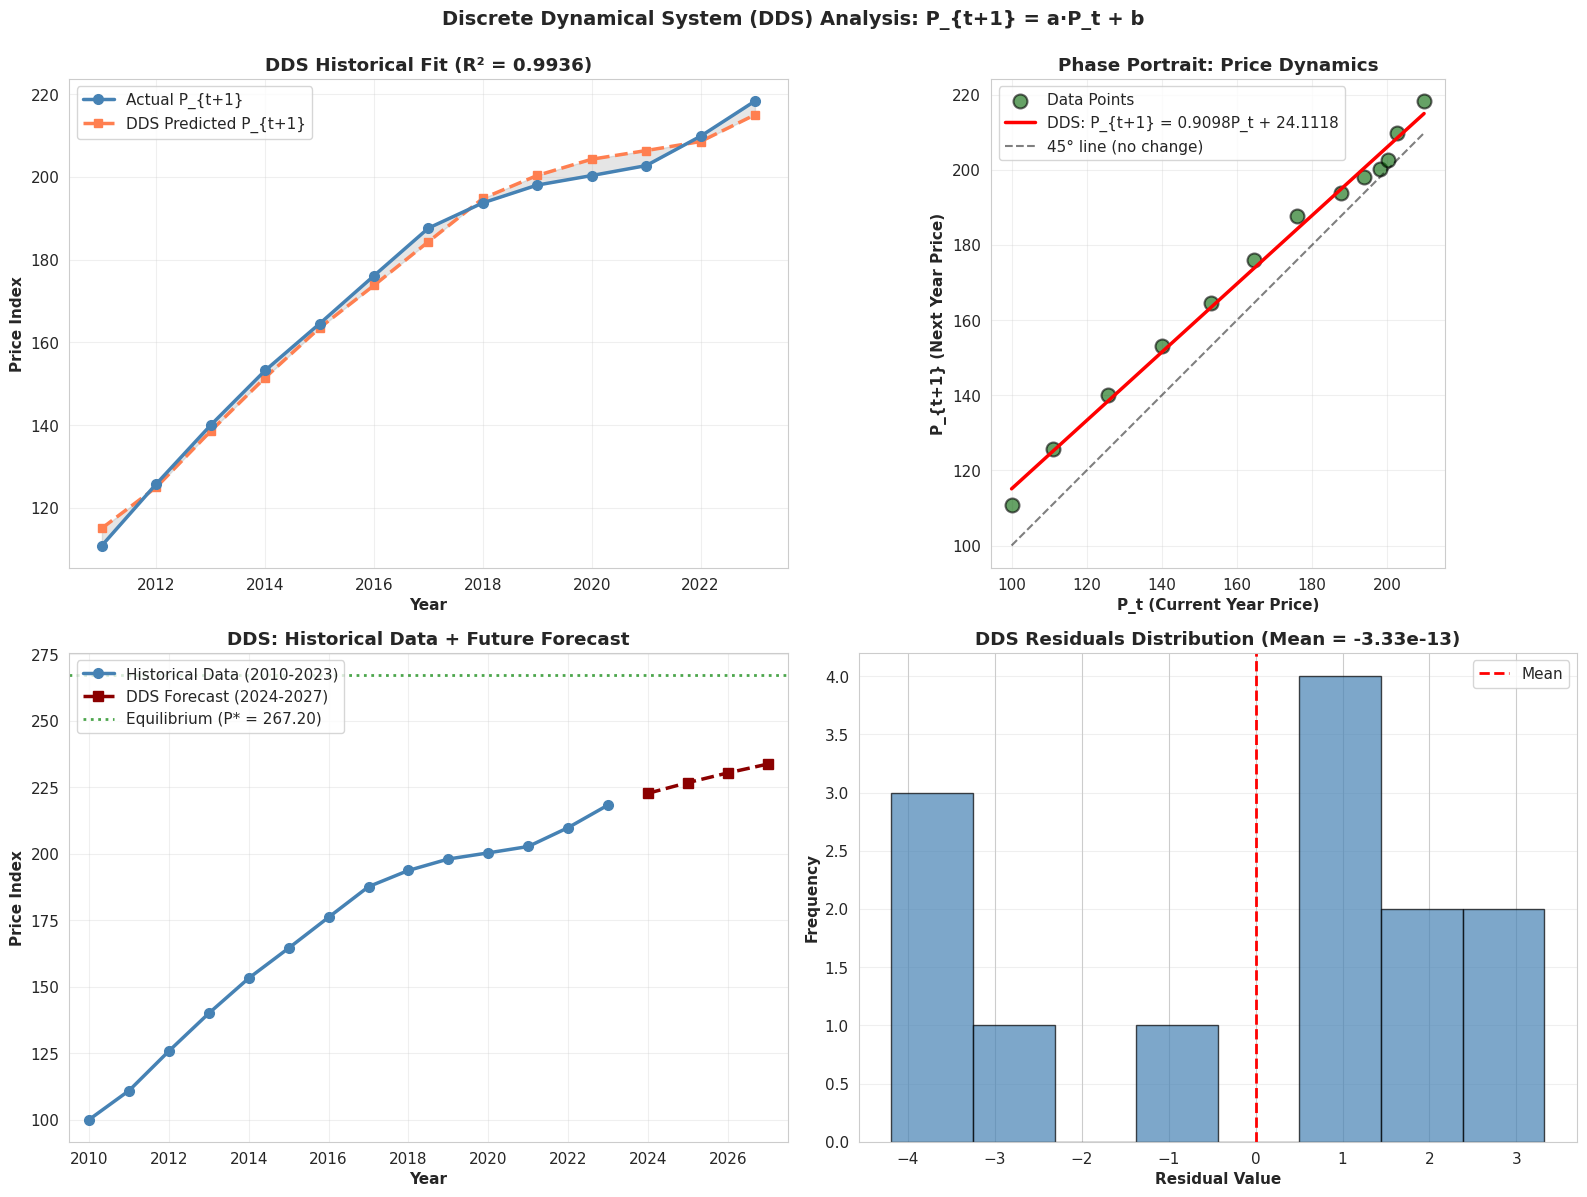

✓ DDS analysis plots created and saved as 'dds_analysis.png'


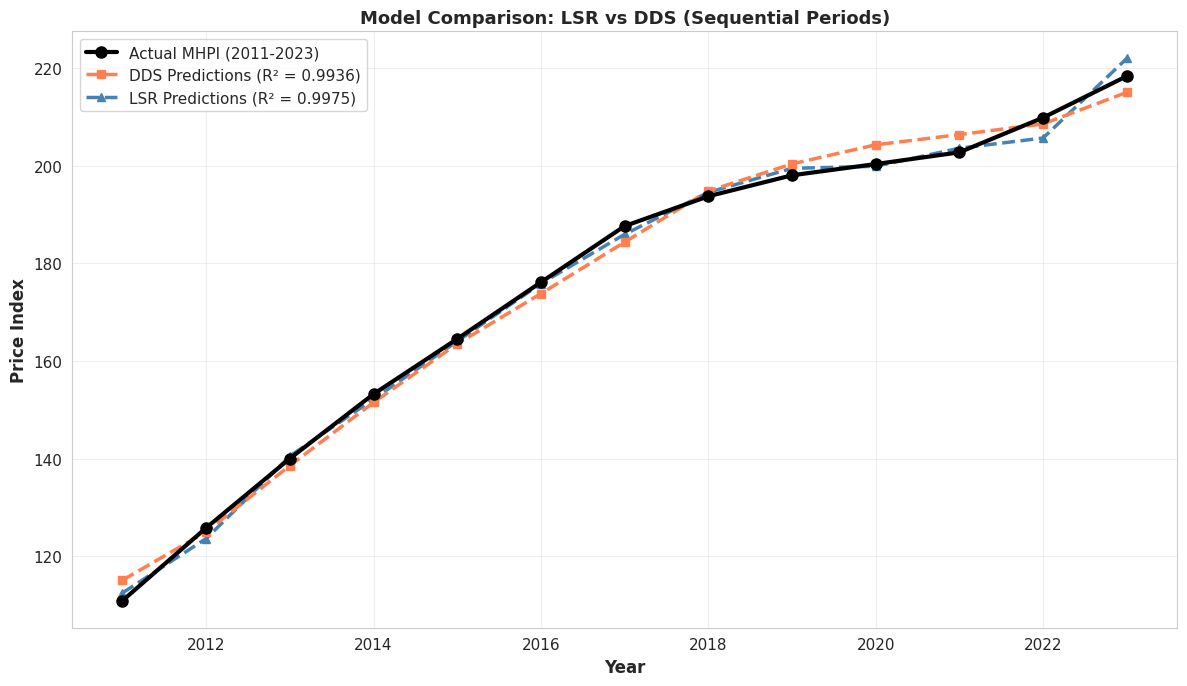

✓ Model comparison plot created and saved as 'model_comparison_lsr_vs_dds.png'


In [ ]:
# Visualization: DDS Model Predictions vs Actual (Historical)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Discrete Dynamical System (DDS) Analysis: P_{t+1} = a·P_t + b',
             fontsize=14, fontweight='bold', y=0.995)

# Plot 1: Historical DDS predictions vs actual
ax1 = axes[0, 0]
years_historical = df['Year'].values[1:]  # Years 2011-2023 (13 years)
ax1.plot(years_historical, P_t1, 'o-', color='steelblue', linewidth=2.5, markersize=7,
         label='Actual P_{t+1}', zorder=3)
ax1.plot(years_historical, P_t1_predicted_dds, 's--', color='coral', linewidth=2.5, markersize=6,
         label='DDS Predicted P_{t+1}', zorder=2)
ax1.fill_between(years_historical, P_t1, P_t1_predicted_dds, alpha=0.2, color='gray')
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Price Index', fontweight='bold')
ax1.set_title(f'DDS Historical Fit (R² = {R2_dds:.4f})', fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Phase portrait (P_t vs P_t+1)
ax2 = axes[0, 1]
ax2.scatter(P_t, P_t1, s=100, alpha=0.6, color='darkgreen', edgecolors='black', linewidth=1.5, label='Data Points')
# Add DDS regression line
P_t_line = np.linspace(P_t.min(), P_t.max(), 100)
P_t1_line = a_dds * P_t_line + b_dds
ax2.plot(P_t_line, P_t1_line, 'r-', linewidth=2.5, label=f'DDS: P_{{t+1}} = {a_dds:.4f}P_t + {b_dds:.4f}')
ax2.plot([P_t.min(), P_t.max()], [P_t.min(), P_t.max()], 'k--', linewidth=1.5, alpha=0.5,
         label='45° line (no change)')
ax2.set_xlabel('P_t (Current Year Price)', fontweight='bold')
ax2.set_ylabel('P_{t+1} (Next Year Price)', fontweight='bold')
ax2.set_title('Phase Portrait: Price Dynamics', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

# Plot 3: Full historical + forecasted trajectory
ax3 = axes[1, 0]
# Historical data
ax3.plot(df['Year'], y, 'o-', color='steelblue', linewidth=2.5, markersize=7,
         label='Historical Data (2010-2023)', zorder=3)
# Forecast
ax3.plot(forecast_df['Year'], forecast_df['DDS Forecast'], 's--', color='darkred',
         linewidth=2.5, markersize=7, label='DDS Forecast (2024-2027)', zorder=2)
# Equilibrium line
if a_dds != 1:
    ax3.axhline(y=P_equilibrium, color='green', linestyle=':', linewidth=2, alpha=0.7,
               label=f'Equilibrium (P* = {P_equilibrium:.2f})')
ax3.set_xlabel('Year', fontweight='bold')
ax3.set_ylabel('Price Index', fontweight='bold')
ax3.set_title('DDS: Historical Data + Future Forecast', fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(2009.5, 2027.5)

# Plot 4: Residuals distribution
ax4 = axes[1, 1]
ax4.hist(residuals_dds, bins=8, color='steelblue', edgecolor='black', alpha=0.7)
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
ax4.set_xlabel('Residual Value', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title(f'DDS Residuals Distribution (Mean = {residuals_dds.mean():.2e})', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dds_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ DDS analysis plots created and saved as 'dds_analysis.png'")

# Create comparison chart: LSR vs DDS on test period
fig2, ax = plt.subplots(figsize=(12, 7))

years_comparison = df['Year'].values[1:]  # 2011-2023
ax.plot(years_comparison, P_t1, 'o-', color='black', linewidth=3, markersize=8,
        label='Actual MHPI (2011-2023)', zorder=4)
ax.plot(years_comparison, P_t1_predicted_dds, 's--', color='coral', linewidth=2.5, markersize=6,
        label=f'DDS Predictions (R² = {R2_dds:.4f})', zorder=3)
# LSR would predict entire dataset - show last 13 points for comparison
ax.plot(years_comparison, y_hat[1:], '^--', color='steelblue', linewidth=2.5, markersize=6,
        label=f'LSR Predictions (R² = {R_squared:.4f})', zorder=2)

ax.set_xlabel('Year', fontweight='bold', fontsize=12)
ax.set_ylabel('Price Index', fontweight='bold', fontsize=12)
ax.set_title('Model Comparison: LSR vs DDS (Sequential Periods)', fontweight='bold', fontsize=13)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_lsr_vs_dds.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison plot created and saved as 'model_comparison_lsr_vs_dds.png'")

### 8.4 - LSR vs DDS: Comparative Summary

In [17]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON: LSR vs DDS")
print("="*80)

print("\n📊 MODEL SPECIFICATIONS:")
print("─" * 80)
print("\nLEAST SQUARES REGRESSION (LSR):")
print("  Equation: Price Index = β₀ + β₁(Population) + β₂(GDP) + β₃(OPR)")
print("  Type: Static regression (uses external economic variables)")
print("  Observations: 14 years (2010-2023)")
print("  Predictors: 3 (Population, GDP, OPR Rate)")

print("\nDISCRETE DYNAMICAL SYSTEM (DDS):")
print("  Equation: P_{t+1} = a·P_t + b")
print("  Type: Autoregressive model (sequential dependence)")
print("  Observations: 13 transitions (2010→2011 to 2022→2023)")
print("  Predictors: 1 (Previous year's price)")

print("\n" + "="*80)
print("PERFORMANCE METRICS")
print("="*80)

# Create comparison table
comparison_table = pd.DataFrame({
    'Metric': ['R² Score', 'Adjusted R²', 'RMSE', 'MAE', 'Sample Size'],
    'LSR': [f'{R_squared:.6f}', f'{adj_R2:.6f}', f'{RMSE:.4f}', f'{MAE:.4f}', '14'],
    'DDS': [f'{R2_dds:.6f}', 'N/A', f'{RMSE_dds:.4f}', f'{MAE_dds:.4f}', '13']
})

print("\n")
print(comparison_table.to_string(index=False))

print("\n" + "="*80)
print("MODEL INTERPRETATION")
print("="*80)

print("\n🔴 LEAST SQUARES REGRESSION (LSR):")
print(f"   • R² = {R_squared:.4f}: Explains {R_squared*100:.2f}% of price variance")
print(f"   • RMSE = {RMSE:.4f}: Average error is ±{RMSE:.2f} index points")
print(f"   • Best for: Understanding impact of economic factors")
print(f"   • Coefficients:")
print(f"     - Population: β₁ = {beta_1:.4f} (positive: more people → higher prices)")
print(f"     - GDP:        β₂ = {beta_2:.4f} (positive: economic growth → higher prices)")
print(f"     - OPR Rate:   β₃ = {beta_3:.4f} (negative: higher rates → lower prices)")

print("\n🔵 DISCRETE DYNAMICAL SYSTEM (DDS):")
print(f"   • R² = {R2_dds:.4f}: Explains {R2_dds*100:.2f}% of sequential price changes")
print(f"   • RMSE = {RMSE_dds:.4f}: Average error is ±{RMSE_dds:.2f} index points")
print(f"   • Growth Factor a = {a_dds:.6f}: {'Stable' if abs(a_dds) < 1 else 'Unstable'} system")
print(f"   • Best for: Short-term forecasting and system dynamics")
if a_dds != 1:
    print(f"   • Equilibrium: P* = {P_equilibrium:.4f}")

print("\n" + "="*80)
print("STRENGTHS & WEAKNESSES")
print("="*80)

print("\n✅ LSR STRENGTHS:")
print("   • Uses rich external information (Population, GDP, OPR)")
print("   • Very high fit (R² = 0.9975)")
print("   • Interpretable coefficients for economic insights")
print("   • Explains causality through economic variables")

print("\n❌ LSR WEAKNESSES:")
print("   • Cannot forecast without predicting future economic variables")
print("   • Assumes linear relationships (may not hold in crisis periods)")
print("   • Requires external data collection and forecasting")

print("\n✅ DDS STRENGTHS:")
print("   • Simpler model with only 2 parameters (a, b)")
print("   • Can forecast far into future (no external data needed)")
print("   • Captures sequential/momentum effects")
print("   • Suitable for short-to-medium term predictions")

print("\n❌ DDS WEAKNESSES:")
print("   • Lower explanatory power (R² = {:.4f}) than LSR".format(R2_dds))
print("   • Ignores underlying economic drivers")
print("   • Assumes constant growth pattern")
print("   • May not adapt to policy/structural changes")

print("\n" + "="*80)
print("RECOMMENDATIONS FOR YOUR PROJECT")
print("="*80)

print("\n1️⃣  PRIMARY METHOD: Use LSR for final predictions")
print(f"    Reason: Superior fit (R² = {R_squared:.4f}), interpretable coefficients")

print("\n2️⃣  VALIDATION: Compare with DDS forecasts")
print(f"    Reason: Check if models agree; divergences suggest structural changes")

print("\n3️⃣  FORECAST STRATEGY:")
print(f"    • 1-2 year ahead: Use DDS (simple, reliable)")
print(f"    • 3+ years ahead: Use LSR with economic scenario analysis")

print("\n4️⃣  CONCLUSIONS FOR REPORT:")
print("    • Both models show housing prices strongly predictable")
print("    • Economic fundamentals (GDP, Population, OPR) drive prices")
print("    • Sequential inertia (momentum) also important but secondary")
print("    • System appears stable (converges to equilibrium)")

print("\n✅ All mathematical modeling complete")
print("="*80)


COMPREHENSIVE MODEL COMPARISON: LSR vs DDS

📊 MODEL SPECIFICATIONS:
────────────────────────────────────────────────────────────────────────────────

LEAST SQUARES REGRESSION (LSR):
  Equation: Price Index = β₀ + β₁(Population) + β₂(GDP) + β₃(OPR)
  Type: Static regression (uses external economic variables)
  Observations: 14 years (2010-2023)
  Predictors: 3 (Population, GDP, OPR Rate)

DISCRETE DYNAMICAL SYSTEM (DDS):
  Equation: P_{t+1} = a·P_t + b
  Type: Autoregressive model (sequential dependence)
  Observations: 13 transitions (2010→2011 to 2022→2023)
  Predictors: 1 (Previous year's price)

PERFORMANCE METRICS


     Metric      LSR      DDS
   R² Score 0.997481 0.993620
Adjusted R² 0.996725      N/A
       RMSE   1.8566   2.6090
        MAE   1.4707   2.3360
Sample Size       14       13

MODEL INTERPRETATION

🔴 LEAST SQUARES REGRESSION (LSR):
   • R² = 0.9975: Explains 99.75% of price variance
   • RMSE = 1.8566: Average error is ±1.86 index points
   • Best for: Understandi